In [1]:
# uv pip install torch torchvision --index-url https://download.pytorch.org/whl/cu126

In [2]:
"""
Modular ECG Analysis Pipeline for Explainable Expert System
- Supports swapping delineators and abnormality detectors
- Outputs a unified DataFrame of detected abnormalities + features
"""
import pandas as pd
from typing import Dict, Any, Tuple, List

import neurokit2 as nk
import ecglib as ecg_lib


# Debug Visualizer

In [8]:
import plotly.graph_objects as go
import plotly.subplots as sp
import numpy as np


class DebugVisualizer:
    """Interactive visualization of ECG signals with delineation points using Plotly"""
    
    # Define visual properties for each peak type
    # Organized by wave (P, Q, R, S, T) with different symbols for onsets, peaks, offsets
    PEAK_STYLES = {
        # P wave - Blue family
        'P_onsets': {'color': 'blue', 'symbol': 'triangle-up', 'size': 9},
        'P_peaks': {'color': 'blue', 'symbol': 'circle', 'size': 9},
        'P2_peaks': {'color': 'blue', 'symbol': 'square', 'size': 9},
        'P_offsets': {'color': 'blue', 'symbol': 'triangle-down', 'size': 9},
        
        # Q wave - Green (only peak)
        'Q_peaks': {'color': 'green', 'symbol': 'circle', 'size': 9},
        
        # R wave - Red family
        'R_onsets': {'color': 'red', 'symbol': 'triangle-up', 'size': 9},
        'R_peaks': {'color': 'red', 'symbol': 'circle', 'size': 9},
        'R_offsets': {'color': 'red', 'symbol': 'triangle-down', 'size': 9},
        
        # S wave - Purple (only peak)
        'S_peaks': {'color': 'mediumpurple', 'symbol': 'circle', 'size': 9},
        
        # T wave - Orange family
        'T_onsets': {'color': 'orange', 'symbol': 'triangle-up', 'size': 9},
        'T_peaks': {'color': 'orange', 'symbol': 'circle', 'size': 9},
        'T2_peaks': {'color': 'orange', 'symbol': 'square', 'size': 9},
        'T_offsets': {'color': 'orange', 'symbol': 'triangle-down', 'size': 9},
    }
    
    def __init__(self, signal, qrs_features, fs: int, channel_names: List[str]):
        """
        Initialize the visualizer
        
        Args:
            signal: Either (n_channels, n_samples) array or dict {lead_name: 1D array}
            qrs_features: Delineation output (list-like by channel index or dict keyed by lead)
            fs: Sampling rate
            channel_names: Optional list of channel names
        """
        self.fs = fs
        self.qrs_features = qrs_features

        if isinstance(signal, dict):
            # Keep only channels that exist in the signal dict, preserving order
            channel_names = [name for name in channel_names if name in signal]

            if len(channel_names) == 0:
                raise ValueError("No valid channels found in signal dictionary")

            stacked_signal = []
            n_samples = None

            for name in channel_names:
                channel = np.asarray(signal[name]).squeeze()
                if channel.ndim != 1:
                    raise ValueError(f"Signal for channel '{name}' must be 1D")

                if n_samples is None:
                    n_samples = channel.shape[0]
                elif channel.shape[0] != n_samples:
                    raise ValueError("All signal channels must have the same number of samples")

                stacked_signal.append(channel)

            self.signal = np.vstack(stacked_signal)
            self.channel_names = channel_names
        else:
            signal_array = np.asarray(signal)
            if signal_array.ndim != 2:
                raise ValueError("Signal array must have shape (n_channels, n_samples)")

            self.signal = signal_array
            if channel_names is None:
                self.channel_names = [f"Channel {i}" for i in range(self.signal.shape[0])]
            else:
                self.channel_names = channel_names

        self.n_channels = self.signal.shape[0]
        self.n_samples = self.signal.shape[1]
        self.time = np.arange(self.n_samples) / fs  # Convert to seconds
    
    def _sanitize_indices(self, indices) -> np.ndarray:
        """Normalize index arrays, drop NaNs, and keep only valid sample indices."""
        indices_arr = np.asarray(indices, dtype=float).ravel()
        indices_arr = indices_arr[~np.isnan(indices_arr)].astype(int)
        return indices_arr[(indices_arr >= 0) & (indices_arr < self.n_samples)]
    
    def _convert_indices_to_time(self, indices) -> np.ndarray:
        """Convert sample indices to time in seconds"""
        indices_clean = self._sanitize_indices(indices)
        return self.time[indices_clean]
    
    def _get_signal_values(self, indices, channel_idx: int) -> np.ndarray:
        """Get signal values at given indices"""
        indices_clean = self._sanitize_indices(indices)
        return self.signal[channel_idx, indices_clean]

    def _get_channel_features(self, channel_idx: int) -> Dict[str, list]:
        """Return delineation features for a channel, supporting list and dict formats."""
        if isinstance(self.qrs_features, dict):
            lead_name = self.channel_names[channel_idx]
            if lead_name in self.qrs_features and isinstance(self.qrs_features[lead_name], dict):
                return self.qrs_features[lead_name]

            if channel_idx in self.qrs_features and isinstance(self.qrs_features[channel_idx], dict):
                return self.qrs_features[channel_idx]

            idx_key = str(channel_idx)
            if idx_key in self.qrs_features and isinstance(self.qrs_features[idx_key], dict):
                return self.qrs_features[idx_key]

            return {}

        if isinstance(self.qrs_features, (list, tuple)) and channel_idx < len(self.qrs_features):
            channel_features = self.qrs_features[channel_idx]
            if isinstance(channel_features, dict):
                return channel_features

        return {}
    
    def plot(self, channel_indices: List[int] = None, height_per_channel: int = 300) -> go.Figure:
        """
        Create interactive plot
        
        Args:
            channel_indices: List of channel indices to plot (default: all)
            height_per_channel: Height in pixels for each subplot
        
        Returns:
            Plotly figure object
        """
        if channel_indices is None:
            channel_indices = list(range(self.n_channels))
        
        # Validate channel indices
        channel_indices = [i for i in channel_indices if 0 <= i < self.n_channels]
        
        n_plots = len(channel_indices)
        height = height_per_channel * n_plots + 100
        
        # Create subplots
        fig = sp.make_subplots(
            rows=n_plots, 
            cols=1,
            subplot_titles=tuple(self.channel_names[i] for i in channel_indices),
            shared_xaxes=True,
            vertical_spacing=0.08
        )
        
        # Add traces for each channel
        for plot_idx, ch_idx in enumerate(channel_indices):
            row = plot_idx + 1
            
            # Add the signal trace
            fig.add_trace(
                go.Scatter(
                    x=self.time,
                    y=self.signal[ch_idx, :],
                    mode='lines',
                    name=f'{self.channel_names[ch_idx]} (signal)',
                    line=dict(color='steelblue', width=1),
                    hovertemplate='<b>Signal</b><br>Time: %{x:.3f}s<br>Amplitude: %{y:.3f}<extra></extra>',
                ),
                row=row, col=1
            )
            
            # Add peaks and offsets for this channel
            features = self._get_channel_features(ch_idx)
            
            for peak_key, peak_indices in features.items():
                # Skip RR which is a single value, not indices
                if peak_key == 'RR':
                    continue
                
                if peak_indices is None or (isinstance(peak_indices, float) and np.isnan(peak_indices)):
                    continue
                
                # Handle case where peak_indices might be a scalar
                if isinstance(peak_indices, (int, float, np.integer)):
                    peak_indices = np.array([peak_indices])
                else:
                    peak_indices = np.array(peak_indices)
                
                if len(peak_indices) == 0:
                    continue
                
                # Get style for this peak type
                style = self.PEAK_STYLES.get(peak_key, {
                    'color': 'gray', 'symbol': 'circle', 'size': 8
                })
                
                # Convert indices to time and get values
                peak_times = self._convert_indices_to_time(peak_indices)
                peak_values = self._get_signal_values(peak_indices, ch_idx)
                
                if len(peak_times) > 0:
                    fig.add_trace(
                        go.Scatter(
                            x=peak_times,
                            y=peak_values,
                            mode='markers',
                            name=peak_key,
                            marker=dict(
                                color=style['color'],
                                symbol=style['symbol'],
                                size=style['size'],
                                line=dict(color='white', width=1)
                            ),
                            hovertemplate=f'<b>{peak_key}</b><br>Time: %{{x:.3f}}s<br>Amplitude: %{{y:.3f}}<extra></extra>',
                        ),
                        row=row, col=1
                    )
        
        # Update layout
        fig.update_layout(
            title_text="ECG Signal with Delineation Points",
            height=height,
            hovermode='x unified',
            font=dict(size=11),
        )
        
        # Update x-axis label
        fig.update_xaxes(title_text="Time (s)", row=n_plots, col=1)
        
        # Update y-axis labels
        for i, _ in enumerate(channel_indices):
            fig.update_yaxes(title_text="Amplitude (mV)", row=i+1, col=1)
        
        return fig
    
    def show(self, channel_indices: List[int] = None):
        """Display the plot"""
        fig = self.plot(channel_indices)
        fig.show()


# 1. DELINEATORS


In [13]:
import wfdb
import matplotlib.pyplot as plt
from signal_utils import expand_to_12_leads

# Load the signal from data/staff_III/001c
record = wfdb.rdrecord('data/staff_III/data/test')
staff_signal = record.p_signal[:5000].T # type: ignore
staff_signal, signal_12ch_names = expand_to_12_leads(staff_signal)

staff_sampling_rate: int = int(record.fs)
staff_channel_names = signal_12ch_names

print(f"Signal shape: {staff_signal.shape}")
print(f"Sampling rate: {staff_sampling_rate} Hz")
print(f"Number of channels: {staff_signal.shape[0]}")
print(f"Channel names: {staff_channel_names}")


Signal shape: (12, 5000)
Sampling rate: 1000 Hz
Number of channels: 12
Channel names: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'I', 'II', 'III', 'aVR', 'aVL', 'aVF']


In [9]:
import ECG.api as api
from delineators import NeuroKitDelineator

nk_delineator = NeuroKitDelineator(staff_channel_names)
cleaned_signal, NK_QRS_features = nk_delineator.delineate(staff_signal, staff_sampling_rate)
# display(NK_QRS_features[2])
visualizer = DebugVisualizer(cleaned_signal, NK_QRS_features, staff_sampling_rate, staff_channel_names)
visualizer.show(channel_indices=[2])

In [11]:
from delineators import WTdelineatorWrapper

WT_delineator = WTdelineatorWrapper(staff_channel_names)

cleaned_signal, WT_QRS_features = WT_delineator.delineate(staff_signal, staff_sampling_rate)
print(staff_channel_names)
# display(WT_QRS_features[2])
visualizer = DebugVisualizer(cleaned_signal, WT_QRS_features, staff_sampling_rate, staff_channel_names)
visualizer.show(channel_indices=[2])


['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'I', 'II', 'III', 'aVR', 'aVL', 'aVF']


In [14]:
from delineators import CombinedDelineator

combined_delineator = CombinedDelineator(staff_channel_names)

cleaned_signal, comb_QRS_features = combined_delineator.delineate(staff_signal, staff_sampling_rate)
print(staff_channel_names)
# display(comb_QRS_features[2])
visualizer = DebugVisualizer(cleaned_signal, comb_QRS_features, staff_sampling_rate, staff_channel_names)
visualizer.show(channel_indices=[2,3])


['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'I', 'II', 'III', 'aVR', 'aVL', 'aVF']


WT P peaks: [nan, 1820.0, nan, 3544.0, 4469.0, nan]
NK P peaks: [nan, 966, 1861, 2749, 3643]
Combined P peaks: [ 966.  1840.5 2749.  3593.5 4469. ]


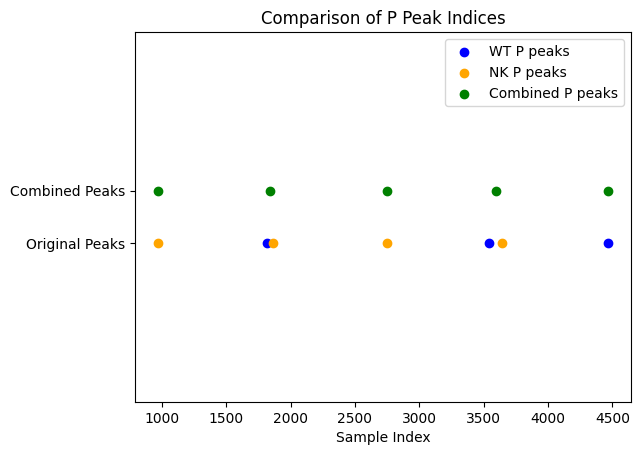

In [15]:
WT_P_peaks = [float("nan"), 1820., float("nan"), 3544., 4469., float("nan")]
NK_P_peaks = [float("nan"), 966, 1861, 2749, 3643]
combined_P_peaks = combined_delineator.merge_arrays(WT_P_peaks, NK_P_peaks)
print("WT P peaks:", WT_P_peaks)
print("NK P peaks:", NK_P_peaks)
print("Combined P peaks:", combined_P_peaks)

plt.scatter(WT_P_peaks, np.zeros_like(WT_P_peaks), color='blue', label='WT P peaks')
plt.scatter(NK_P_peaks, np.zeros_like(NK_P_peaks), color='orange', label='NK P peaks')
plt.scatter(combined_P_peaks, np.ones_like(combined_P_peaks), color='green', label='Combined P peaks')
plt.yticks([0, 1], ['Original Peaks', 'Combined Peaks'])
plt.xlabel('Sample Index')
plt.ylim(-3, 4)
plt.title('Comparison of P Peak Indices')
plt.legend()
plt.show()

# 2. ABNORMALITY DETECTORS (Swappable)

In [19]:
comb_QRS_features["V1"]

{'P_onsets': array([ 611. ,  868. , 1742. , 2563. , 3519.5, 4398. ]),
 'T_onsets': array([1215., 2114., 3026., 3934., 4720.]),
 'S_peaks': array([ 260., 1074., 1969., 2857., 3752., 4632.]),
 'T_peaks': array([1308., 2205., 3092., 3977., 4848.]),
 'P2_peaks': array([nan, nan, nan, nan, nan, nan]),
 'RR': 890,
 'R_offsets': array([ 285. , 1115. , 2010.5, 2898.5, 3793. , 4672.5]),
 'P_offsets': array([ 715. ,  955. , 1811.5, 2516. , 2738. , 3588. , 4473.5]),
 'P_peaks': array([ 935. , 1830. , 2718. , 3614. , 4475.5]),
 'T_offsets': array([1390., 2287., 3172., 4069., 4786.]),
 'T2_peaks': array([nan, nan, nan, nan, nan, nan]),
 'R_peaks': array([ 189. , 1052.5, 1948. , 2836. , 3732. , 4611.5]),
 'R_onsets': array([ 137. ,  966.5, 1862. , 2750.5, 3647. , 4526. ]),
 'Q_peaks': array([ 949., 1844., 2732., 3628., 4508.])}

In [20]:
from ecg_features import METRIC_REGISTRY
METRIC_REGISTRY

{'heart_rate': <function ecg_features.metric_heart_rate(ecg: numpy.ndarray, fs: int, delineation: Dict, **kwargs) -> float>,
 'hr_min': <function ecg_features.metric_hr_min(ecg: numpy.ndarray, fs: int, delineation: Dict, **kwargs) -> float>,
 'hr_max': <function ecg_features.metric_hr_max(ecg: numpy.ndarray, fs: int, delineation: Dict, **kwargs) -> float>,
 'pr_interval': <function ecg_features.metric_PR_interval(ecg: numpy.ndarray, fs: int, delineation: Dict, **kwargs) -> float>,
 'qrs_duration': <function ecg_features.metric_QRS_duration(ecg: numpy.ndarray, fs: int, delineation: Dict, **kwargs) -> float>,
 'qt_interval': <function ecg_features.metric_QT_interval(ecg: numpy.ndarray, fs: int, delineation: Dict, **kwargs) -> float>,
 'jt_interval': <function ecg_features.metric_JT_interval(ecg: numpy.ndarray, fs: int, delineation: Dict, **kwargs) -> float>,
 'qtc_bazett': <function ecg_features.metric_QTc_Bazett(ecg: numpy.ndarray, fs: int, delineation: Dict, **kwargs) -> float>,
 'qtc_

In [21]:
METRIC_REGISTRY["heart_rate"]

<function ecg_features.metric_heart_rate(ecg: numpy.ndarray, fs: int, delineation: Dict, **kwargs) -> float>

In [ ]:
class AbnormalityDetectorInterface:
    """Abstract interface for abnormality detection"""
    def detect(self, ecg: np.ndarray, fs: int, delineation: Dict[str, Dict[str, np.ndarray]], **kwargs) -> pd.DataFrame:
        raise NotImplementedError

import ECG.api as api

class AimClubECGDetector(AbnormalityDetectorInterface):
    """aimclub/ECG - best for multiple diagnostic outputs"""
    def detect(self, ecg: np.ndarray, fs: int, delineation: Dict[str, Dict[str, np.ndarray]], **kwargs) -> pd.DataFrame:
        analyzer = api.ECG()
        # Most libraries accept raw signal; pass delineation if supported
        results = analyzer.analyze(ecg, sampling_rate=fs, **kwargs)
        
        # Convert to DataFrame (adapt based on actual output structure)
        df = pd.DataFrame({
            'abnormality': list(results.keys()),
            'present': list(results.values()),
            'confidence': [res.get('prob', 1.0) for res in results.values()] if isinstance(results, dict) else None,
            'leads_affected': [...]  # extract if available
        })
        return df


class EcglibAbnormalityDetector(AbnormalityDetectorInterface):
    """ecglib - pretrained models for pathologies"""
    
    def clean_signal(self, signal, sampling_rate):
        return np.stack(
            [nk.ecg_clean(channel, sampling_rate=sampling_rate) for channel in signal], # type: ignore
            axis=0,
        ) # type: ignore
    
    def get_ste(self,ecg_signal, sampling_rate):
        _, ecg_cleaned_2 = get_channel(ecg_signal, sampling_rate, '2')
        ecg_parameters = get_ecg_parameters(ecg_cleaned_2, sampling_rate)

        return get_median_ste60(ecg_signal, sampling_rate, ecg_parameters)
    
    def detect_ST60_elevation(self, ecg: pd.DataFrame, fs: int, delineation: Dict[str, list[int]], elevation_threshold=0.2) -> pd.DataFrame:
        ste_mV = self.get_ste(ecg, fs)
        ste_bool = ste_mV > elevation_threshold
    
    def detect(self, ecg: pd.DataFrame, fs: int, delineation: Dict[str, list[int]], **kwargs) -> pd.DataFrame:
        """
        Run ecglib's pretrained pathology detection model on the ECG signal
        
        ecg: (n_channels, n_samples) ECG signal array
        fs: Sampling rate
        delineation: Dict of delineation points
        """
        
        # Example usage - adapt to actual API
        record = ecg_lib.EcgRecord(ecg, fs=fs)
        predictions = record.predict_pathologies()  # or similar
        
        # Convert to DataFrame
        df = pd.DataFrame.from_dict(predictions, orient='index', columns=['probability'])
        df['present'] = df['probability'] > 0.5
        df.reset_index(names='abnormality', inplace=True)
        return df


# class NeuroKitAnalyzer(AbnormalityDetectorInterface):
#     """NeuroKit2 as feature + rule-based analyzer"""
#     def detect(self, ecg: np.ndarray, fs: int, delineation: Dict = None, **kwargs) -> pd.DataFrame:
#         df_features, _ = nk.ecg_analyze(ecg, sampling_rate=fs, method="interval")
#         # Add custom rule-based abnormalities here (e.g., ST elevation using delineation)
#         abnormalities = self._apply_wellens_rules(ecg, fs, delineation, df_features)
#         return pd.DataFrame(abnormalities)

In [33]:
import pickle as pkl

with open("data/LU_DB/maps/data.pkl", "rb") as f:
    data = pkl.load(f)

metadata = pd.read_csv("data/LU_DB/maps/metadata.csv", index_col=0)
sampling_rate = metadata.loc["data/1"]["fs"]
signal = data.loc["data/1"]
signal[signal.index[0]]
signal["I"]
# # cleaned_data = 
# np.stack(
#     [nk.ecg_clean(channel, sampling_rate=sampling_rate) for channel in data], # type: ignore
#     axis=0,
# )

array([-0.07342657, -0.02855478,  0.01689977, ..., -0.04079254,
       -0.03671329, -0.04195804], shape=(5000,))

# 3. MAIN PIPELINE

In [ ]:
from delineators import DelineatorInterface

class ECGExpertPipeline:
    def __init__(self, delineator: DelineatorInterface, detector: AbnormalityDetectorInterface):
        self.delineator = delineator
        self.detector = detector

    def process(self, ecg: np.ndarray, fs: int, **kwargs) -> Tuple[Dict, pd.DataFrame]:
        # Step 1: Delineation
        delineation = self.delineator.delineate(ecg, fs, **kwargs)
        
        # Step 2: Abnormality detection
        abnormalities_df = self.detector.detect(ecg, fs, delineation, **kwargs)
        
        return delineation, abnormalities_df

# 4. USAGE EXAMPLE

In [ ]:
record = wfdb.rdrecord('data/staff_III/example_record')  # adjust path
record

FileNotFoundError: [Errno 2] No such file or directory: 'c:/Users/staso/OneDrive/Pulpit/Nauka/University/Thesis/code/ECG_Delineation/WTdelineator/staffiii/example_record.hea'

In [ ]:
# Load example signal (e.g., from STAFF III)
record = wfdb.rdrecord('staffiii/example_record')  # adjust path
ecg = record.p_signal[:, 0]  # e.g., lead I
fs = record.fs

# === Swappable combinations ===
pipeline1 = ECGExpertPipeline(
    delineator=WTdelineatorWrapper(),
    detector=AimClubECGDetector()
)

pipeline2 = ECGExpertPipeline(
    delineator=NeuroKitDelineator(),
    detector=EcglibDetector()
)

# Run
delineation, abnorm_df = pipeline1.process(ecg, fs)

print("Detected Abnormalities:")
print(abnorm_df[abnorm_df['present'] == True])

# Save for your knowledge graph
abnorm_df.to_csv("abnormalities.csv", index=False)
